In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

## DEPTH = 6
# === CONFIG ===
TRAIN_PATH = r'C:\Users\HP\Documents\SCALE-UP\SCALE-UP+ELIMINATION+ROUND+CASE+AND+PROBLEM\Train dataset'
TEST_PATH = r'C:\Users\HP\Documents\SCALE-UP\SCALE-UP+ELIMINATION+ROUND+CASE+AND+PROBLEM\Test_dataset.csv'
OUTPUT_PATH = r'C:\Users\HP\Documents\SCALE-UP\SCALE-UP+ELIMINATION+ROUND+CASE+AND+PROBLEM\LGBM_8_800_lithology_predictions.csv'

In [32]:
# === Lithology Mapping ===
lithology_mapping = {
    30000: 'Sandstone',
    65030: 'Sandstone/Shale',
    65000: 'Shale',
    80000: 'Marl',
    74000: 'Dolomite',
    70000: 'Limestone',
    70032: 'Chalk',
    88000: 'Halite',
    86000: 'Anhydrite',
    99000: 'Tuff',
    90000: 'Coal',
    93000: 'Basement'
}

In [33]:

# === Function to load and preprocess well data ===
def load_well_data(folder_path):
    files = glob.glob(os.path.join(folder_path, "*.csv"))
    df_list = []
    
    for file in files:
        try:
            df = pd.read_csv(file)
            # Extract well name from file path
            well_name = os.path.basename(file).split('.')[0]
            df['well_name'] = well_name
            df_list.append(df)
        except Exception as e:
            print(f"Error loading {file}: {e}")
    
    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()


In [34]:
# === Load data ===
print("Loading training data...")
train_data = load_well_data(TRAIN_PATH)
if train_data.empty:
    raise ValueError("No training data found!")

print(f"Loaded {train_data['well_name'].nunique()} training wells with {train_data.shape[0]} rows")

print("Loading test data...")
test_data = pd.read_csv(TEST_PATH)
if test_data.empty:
    raise ValueError("Test dataset is empty!")

print(f"Loaded test data with {test_data.shape[0]} rows")

Loading training data...
Loaded 31 training wells with 304281 rows
Loading test data...
Loaded test data with 121797 rows


In [35]:
train_data.isnull().sum()

file_name              0
filename          304281
Lithology_code     53881
ROPA              282201
BS                164623
PEF               154822
RXO               236168
DCAL              233798
RMIC              275741
ROP                59884
SP                 88024
RMED               26576
GR                  3845
DTC                39246
MUDWEIGHT         129899
Y_LOC               7543
DRHO               92338
DEPTH_MD            7543
DTS               290768
RHOB               93394
NPHI              166872
SGR               286863
X_LOC               7543
CALI               62918
RSHA              169270
Z_LOC               7543
RDEP                3845
DEPT                   0
well_name              0
dtype: int64

In [36]:
test_data.isnull().sum()

uuid              0
file_name         0
ROPA          91731
BS            31887
PEF           35338
RXO          115090
DCAL          80633
RMIC         106867
ROP           33884
SP            46264
RMED          13875
GR                3
DTC             859
MUDWEIGHT     88433
Y_LOC          7429
DRHO          26500
DEPTH_MD       7429
DTS           96453
RHOB          25619
NPHI          43576
SGR          120658
X_LOC          7429
CALI              7
RSHA          59427
Z_LOC          7429
RDEP           7429
DEPT              0
dtype: int64

In [5]:
# === Convert all columns to numeric where possible ===
def convert_to_numeric(df, exclude_cols=['file_name', 'well_name', 'Lithology_code', 'Lithology_Label']):
    for col in df.columns:
        if col not in exclude_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert, force errors to NaN
    return df

# Convert columns to numeric
train_data = convert_to_numeric(train_data)
test_data = convert_to_numeric(test_data)

In [6]:
# Add Lithology Labels
train_data['Lithology_Label'] = train_data['Lithology_code'].map(lithology_mapping)

# Drop rows with missing lithology values
train_data.dropna(subset=['Lithology_Label'], inplace=True)

In [7]:
train_data

,file_name,filename,Lithology_code,ROPA,BS,PEF,RXO,DCAL,RMIC,ROP,...,NPHI,SGR,X_LOC,CALI,RSHA,Z_LOC,RDEP,DEPT,well_name,Lithology_Label
3089,15_9-13_part_1,NaN,65000.0,NaN,NaN,20.915468,NaN,NaN,NaN,34.636410,...,NaN,NaN,437641.96880,19.480835,NaN,-469.501831,80.200851,494.528,15_9-13_part_1,Shale
3090,15_9-13_part_1,NaN,65000.0,NaN,NaN,19.383013,NaN,NaN,NaN,34.636410,...,NaN,NaN,437641.96880,19.468800,NaN,-469.653809,79.262886,494.680,15_9-13_part_1,Shale
3091,15_9-13_part_1,NaN,65000.0,NaN,NaN,22.591518,NaN,NaN,NaN,34.779556,...,NaN,NaN,437641.96880,19.468800,NaN,-469.805786,74.821999,494.832,15_9-13_part_1,Shale
3092,15_9-13_part_1,NaN,65000.0,NaN,NaN,32.191910,NaN,NaN,NaN,39.965164,...,NaN,NaN,437641.96880,19.459282,NaN,-469.957794,72.878922,494.984,15_9-13_part_1,Shale
3093,15_9-13_part_1,NaN,65000.0,NaN,NaN,38.495632,NaN,NaN,NaN,57.483765,...,NaN,NaN,437641.96880,19.453100,NaN,-470.109772,71.729141,495.136,15_9-13_part_1,Shale
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304217,30_3-3_part_2,NaN,30000.0,NaN,NaN,NaN,4.063,NaN,NaN,NaN,...,0.235785,NaN,497358.37500,NaN,4.0625,-3404.430664,2799.554429,3426.806,30_3-3_part_2,Sandstone
304218,30_3-3_part_2,NaN,30000.0,NaN,NaN,NaN,4.063,NaN,NaN,NaN,...,0.239300,NaN,497358.40625,NaN,4.0625,-3404.582764,45.047577,3426.958,30_3-3_part_2,Sandstone
304219,30_3-3_part_2,NaN,30000.0,NaN,NaN,NaN,4.063,NaN,NaN,NaN,...,0.239300,NaN,497358.40625,NaN,4.0625,-3404.734863,45.050072,3427.110,30_3-3_part_2,Sandstone
304220,30_3-3_part_2,NaN,30000.0,NaN,NaN,NaN,4.063,NaN,NaN,NaN,...,0.239300,NaN,497358.40625,NaN,4.0625,-3404.886719,44.384651,3427.262,30_3-3_part_2,Sandstone


In [8]:
# === FEATURE ENGINEERING (Simplified) ===
def engineer_features(df):
    # Copy the dataframe to avoid modifying the original
    df_new = df.copy()
    
    # === Core ratios only (minimizing features) ===
    # Focus on the most petrophysically significant combinations
    
    # GR-based shale volume (critical for lithology)
    if 'GR' in df_new.columns and df_new['GR'].notna().any():
        # Calculate per-well GR normalization to avoid data leakage
        if 'well_name' in df_new.columns:
            for well in df_new['well_name'].unique():
                well_mask = df_new['well_name'] == well
                if df_new.loc[well_mask, 'GR'].notna().sum() > 10:  # Ensure enough data points
                    gr_min = df_new.loc[well_mask, 'GR'].quantile(0.05)
                    gr_max = df_new.loc[well_mask, 'GR'].quantile(0.95)
                    if gr_max > gr_min:  # Prevent division by zero
                        df_new.loc[well_mask, 'VSH_GR'] = (df_new.loc[well_mask, 'GR'] - gr_min) / (gr_max - gr_min)
                        df_new.loc[well_mask, 'VSH_GR'] = df_new.loc[well_mask, 'VSH_GR'].clip(0, 1)
    
    # Density-neutron combination (critical lithology indicator)
    if 'RHOB' in df_new.columns and 'NPHI' in df_new.columns:
        mask = df_new['RHOB'].notna() & df_new['NPHI'].notna()
        if mask.any():
            df_new.loc[mask, 'RHOB_NPHI_DIFF'] = df_new.loc[mask, 'RHOB'] - df_new.loc[mask, 'NPHI']
    
    # Resistivity ratio (important for fluid content) 
    if 'RDEP' in df_new.columns and 'RSHA' in df_new.columns:
        mask = df_new['RDEP'].notna() & df_new['RSHA'].notna() & (df_new['RSHA'] > 0)
        if mask.any():
            df_new.loc[mask, 'RES_RATIO'] = df_new.loc[mask, 'RDEP'] / df_new.loc[mask, 'RSHA']
            df_new.loc[mask, 'RES_RATIO'] = df_new.loc[mask, 'RES_RATIO'].clip(0, 100)  # Clip outliers
    
    return df_new

In [9]:
# Apply feature engineering
train_data = engineer_features(train_data)
test_data = engineer_features(test_data)

In [10]:

# === EXCLUDE SPATIAL LOCATION FEATURES ===
location_columns = ['X_LOC', 'Y_LOC', 'Z_LOC', 'DEPT', 'DEPTH_MD']
print(f"Excluding location columns: {[col for col in location_columns if col in train_data.columns]}")

Excluding location columns: ['X_LOC', 'Y_LOC', 'Z_LOC', 'DEPT', 'DEPTH_MD']


In [11]:
# Select Features & Target
excluded_columns = ['file_name', 'well_name', 'Lithology_code', 'Lithology_Label', 'filename', 'ROPA','BS', 'SGR', 'RXO', 'RMIC', 'DTS'] + location_columns
feature_columns = [col for col in train_data.columns if col not in excluded_columns]

In [12]:
feature_columns

['PEF',
 'DCAL',
 'ROP',
 'SP',
 'RMED',
 'GR',
 'DTC',
 'MUDWEIGHT',
 'DRHO',
 'RHOB',
 'NPHI',
 'CALI',
 'RSHA',
 'RDEP',
 'VSH_GR',
 'RHOB_NPHI_DIFF',
 'RES_RATIO']

In [13]:
X = train_data[feature_columns].copy()
y = train_data['Lithology_code']

In [17]:
# Print feature list after exclusion
print(f"Using {X.shape[1]} features for training: {X.columns.tolist()}")

# Fill missing values with median
X.fillna(X.median(numeric_only=True), inplace=True)

Using 17 features for training: ['PEF', 'DCAL', 'ROP', 'SP', 'RMED', 'GR', 'DTC', 'MUDWEIGHT', 'DRHO', 'RHOB', 'NPHI', 'CALI', 'RSHA', 'RDEP', 'VSH_GR', 'RHOB_NPHI_DIFF', 'RES_RATIO']


In [18]:
# === TRAIN/TEST SPLIT ===
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [25]:
X_valid

,PEF,DCAL,ROP,SP,RMED,GR,DTC,MUDWEIGHT,DRHO,RHOB,NPHI,CALI,RSHA,RDEP,VSH_GR,RHOB_NPHI_DIFF,RES_RATIO
215469,4.139692,0.431729,3.005460,17.545633,0.508874,17.871580,159.288406,0.127016,-0.017777,1.202185,0.354116,22.812500,1.052220,17.871580,0.000655,1.960604,63.769794
272883,3.774589,0.431729,17.485909,57.706097,1.669169,44.204159,130.590820,0.152180,0.005983,2.156461,0.354116,13.304518,1.052220,44.204159,0.006110,1.960604,63.769794
18421,7.381997,0.431729,5.361251,110.623428,1.743112,86.183250,91.037201,0.156973,0.114523,2.338609,0.366427,9.509518,1.023704,86.183250,0.024167,1.972182,84.187691
26501,1.708000,0.431729,132.068237,23.026598,0.737643,29.523075,145.854279,0.133007,-0.004181,2.017310,0.354116,17.569918,1.052220,29.523075,0.000534,1.960604,63.769794
298874,3.774589,0.431729,17.485909,60.266384,2.023400,2835.868436,104.791946,0.152180,-0.024619,2.444602,0.354116,13.359400,2.984400,2835.868436,0.924773,1.960604,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103978,2.901248,0.037913,44.180923,57.706097,1.373079,89.232697,130.590820,0.152180,0.050276,2.362808,0.235756,8.537913,1.052220,89.232697,0.018656,2.127052,63.769794
301961,3.774589,0.431729,17.485909,28.175346,2.698101,38.788872,81.450912,0.152180,0.021905,2.343693,0.182108,8.281200,2.355096,38.788872,0.004045,2.161584,16.470188
174090,3.774589,0.431729,16.153156,57.706097,1.021535,64.773865,127.548225,0.152180,0.088318,2.445990,0.366783,14.378619,0.294064,64.773865,0.016053,2.079207,100.000000
173399,3.774589,0.431729,8.851133,57.706097,1.131877,59.110039,130.590820,0.152180,0.024863,2.470254,0.269755,15.317073,0.309607,59.110039,0.014133,2.200499,100.000000


In [26]:
y_valid

215469    30000.0
272883    65000.0
18421     65000.0
26501     30000.0
298874    65000.0
           ...   
103978    65030.0
301961    30000.0
174090    65000.0
173399    65000.0
87215     65000.0
Name: Lithology_code, Length: 50080, dtype: float64

In [24]:
# === IMPROVE MODEL FOR SANDSTONE/SHALE DISCRIMINATION ===
# Get class distribution
class_counts = y_train.value_counts().sort_index()
print("\nClass distribution in training data:")
for code, count in class_counts.items():
    label = lithology_mapping.get(code, 'Unknown')
    print(f"{code} ({label}): {count} samples, {count/len(y_train)*100:.2f}%")


Class distribution in training data:
30000.0 (Sandstone): 35084 samples, 17.51%
65000.0 (Shale): 115973 samples, 57.89%
65030.0 (Sandstone/Shale): 16227 samples, 8.10%
70000.0 (Limestone): 13414 samples, 6.70%
70032.0 (Chalk): 4274 samples, 2.13%
74000.0 (Dolomite): 887 samples, 0.44%
80000.0 (Marl): 6596 samples, 3.29%
86000.0 (Anhydrite): 736 samples, 0.37%
88000.0 (Halite): 3135 samples, 1.56%
90000.0 (Coal): 822 samples, 0.41%
93000.0 (Basement): 113 samples, 0.06%
99000.0 (Tuff): 3059 samples, 1.53%


In [ ]:
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import f1_score
    import numpy as np

    # === 5-Fold Cross-Validation ===
    n_splits = 5
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    cv_f1_scores = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y)):
        print(f"\nTraining Fold {fold+1}/{n_splits}...")
        
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        
        # Train Model with More Regularization
        model = LGBMClassifier(
            n_estimators=850, 
            learning_rate=0.05,
            max_depth=6,  # Reduced from 8 to 6
            reg_lambda=5,  # Increased for better regularization
            min_child_samples=50,  # Prevents small leaf nodes
            random_state=42,
            objective='multiclass',
            class_weight='balanced',
            verbose=-1  
        )
        
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)])
        
        # Validate Model
        y_valid_pred = model.predict(X_valid)
        f1 = f1_score(y_valid, y_valid_pred, average='weighted')
        cv_f1_scores.append(f1)
        print(f"Fold {fold+1} F1 Score: {f1:.4f}")

    # === Cross-Validation Results ===
    mean_f1 = np.mean(cv_f1_scores)
    std_f1 = np.std(cv_f1_scores)
    print(f"\nCross-Validation Mean F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

    # Retrain Model on Full Training Set
    print("\nRetraining final model on full training set...")
    model.fit(X, y)



Training Fold 1/5...
Fold 1 F1 Score: 0.9018

Training Fold 2/5...
Fold 2 F1 Score: 0.9010

Training Fold 3/5...
Fold 3 F1 Score: 0.9009

Training Fold 4/5...
Fold 4 F1 Score: 0.9004

Training Fold 5/5...
Fold 5 F1 Score: 0.8994

Cross-Validation Mean F1 Score: 0.9007 ± 0.0008

Retraining final model on full training set...


LGBMClassifier(class_weight='balanced', learning_rate=0.05, max_depth=6,
               min_child_samples=50, n_estimators=850, objective='multiclass',
               random_state=42, reg_lambda=5, verbose=-1)


Training Fold 1/5...
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[850]	train's multi_logloss: 0.0706131	valid's multi_logloss: 0.271684
Fold 1 F1 Score: 0.9086

Training Fold 2/5...
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[850]	train's multi_logloss: 0.0716126	valid's multi_logloss: 0.275583
Fold 2 F1 Score: 0.9088

Training Fold 3/5...
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[850]	train's multi_logloss: 0.0715141	valid's multi_logloss: 0.275111
Fold 3 F1 Score: 0.9074

Training Fold 4/5...
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[850]	train's multi_logloss: 0.0716035	valid's multi_logloss: 0.277806
Fold 4 F1 Score: 0.9080

Training Fold 5/5...
Training until validation scores don't improve for 30 rounds
Did not meet 

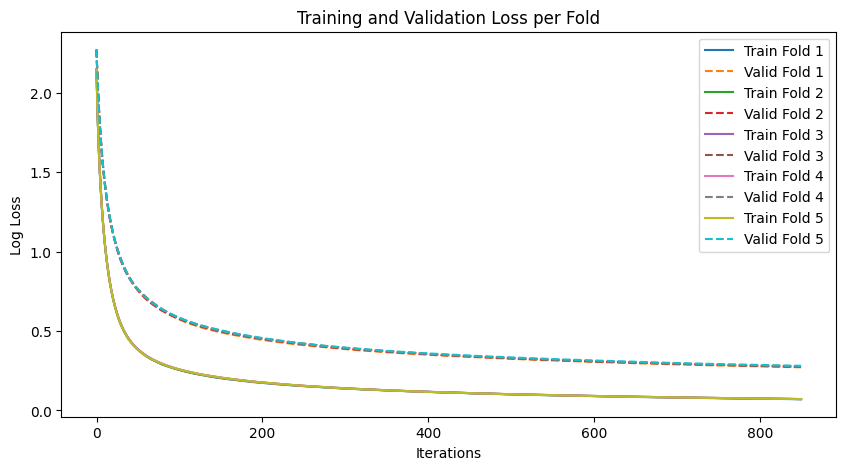


Cross-Validation Mean F1 Score: 0.9076 ± 0.0012

Retraining final model on full training set...


LGBMClassifier(class_weight='balanced', learning_rate=0.05, max_depth=8,
               min_child_samples=50, n_estimators=850, objective='multiclass',
               random_state=42, reg_lambda=5, verbose=-1)

In [ ]:
from lightgbm.callback import early_stopping, record_evaluation

splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_f1_scores = []
training_losses = []
validation_losses = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y)):
    print(f"\nTraining Fold {fold+1}/{n_splits}...")
    
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    
    model = LGBMClassifier(
        n_estimators=850, 
        learning_rate=0.05,
        max_depth=8,  
        reg_lambda=5,
        min_child_samples=50,
        random_state=42,
        objective='multiclass',
        class_weight='balanced',
        verbose=-1
    )
    
    evals_result = {}
    eval_names = ['train', 'valid'] 
    model.fit( X_train, y_train, 
              eval_set=[(X_train, y_train), (X_valid, y_valid)],
              eval_names=eval_names,
              eval_metric='multi_logloss',  
              callbacks=[record_evaluation(evals_result),   
               early_stopping(stopping_rounds=30, verbose=True)]
)

    training_losses.append(evals_result['train']['multi_logloss'])
    validation_losses.append(evals_result['valid']['multi_logloss'])

    
    y_valid_pred = model.predict(X_valid)
    f1 = f1_score(y_valid, y_valid_pred, average='weighted')
    cv_f1_scores.append(f1)
    print(f"Fold {fold+1} F1 Score: {f1:.4f}")

# Plot Training and Validation Loss
plt.figure(figsize=(10, 5))
for i in range(n_splits):
    plt.plot(training_losses[i], label=f'Train Fold {i+1}')
    plt.plot(validation_losses[i], label=f'Valid Fold {i+1}', linestyle='dashed')
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("Training and Validation Loss per Fold")
plt.legend()
plt.show()

# === Cross-Validation Results ===
mean_f1 = np.mean(cv_f1_scores)
std_f1 = np.std(cv_f1_scores)
print(f"\nCross-Validation Mean F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

# Retrain Model on Full Training Set
print("\nRetraining final model on full training set...")
final_model = LGBMClassifier(
    n_estimators=850, 
    learning_rate=0.05,
    max_depth=8,
    reg_lambda=5,
    min_child_samples=50,
    random_state=42,
    objective='multiclass',
    class_weight='balanced',
    verbose=-1
)
final_model.fit(X, y)


In [26]:
# Get and print detailed classification report
class_report = classification_report(y_valid, y_valid_pred, 
                                    target_names=[lithology_mapping.get(code, 'Unknown') for code in model.classes_],
                                    output_dict=True)

# Convert classification report to DataFrame for better formatting
report_df = pd.DataFrame(class_report).transpose()
print("\nDetailed Classification Report:")
print(report_df.to_string(float_format='%.2f'))


Detailed Classification Report:
                 precision  recall  f1-score  support
Sandstone             0.92    0.90      0.91  8771.00
Shale                 0.98    0.88      0.93 28993.00
Sandstone/Shale       0.63    0.87      0.73  4057.00
Limestone             0.85    0.89      0.87  3353.00
Chalk                 0.96    0.98      0.97  1068.00
Dolomite              0.24    0.76      0.36   222.00
Marl                  0.77    0.95      0.85  1649.00
Anhydrite             0.93    0.90      0.91   184.00
Halite                0.98    0.99      0.98   783.00
Coal                  0.68    0.87      0.77   206.00
Basement              1.00    1.00      1.00    29.00
Tuff                  0.69    0.97      0.81   765.00
accuracy              0.89    0.89      0.89     0.89
macro avg             0.80    0.91      0.84 50080.00
weighted avg          0.91    0.89      0.90 50080.00



Classification Report in required format:
Classification Report:
               precision    recall  f1-score   support
 30000.0 0.92        0.90     0.91     8771
 65000.0 0.98        0.88     0.93     28993
 65030.0 0.63        0.87     0.73     4057
 70000.0 0.85        0.89     0.87     3353
 70032.0 0.96        0.98     0.97     1068
 74000.0 0.24        0.76     0.36     222
 80000.0 0.77        0.95     0.85     1649
 86000.0 0.93        0.90     0.91     184
 88000.0 0.98        0.99     0.98     783
 90000.0 0.68        0.87     0.77     206
 93000.0 1.00        1.00     1.00     29
 99000.0 0.69        0.97     0.81     765
accuracy                                          0.89     50080
macro avg     0.80        0.91     0.84     50080
weighted avg  0.91        0.89     0.90     50080

Generating confusion matrix...
Confusion matrix saved as 'lithology_confusion_matrix.png'


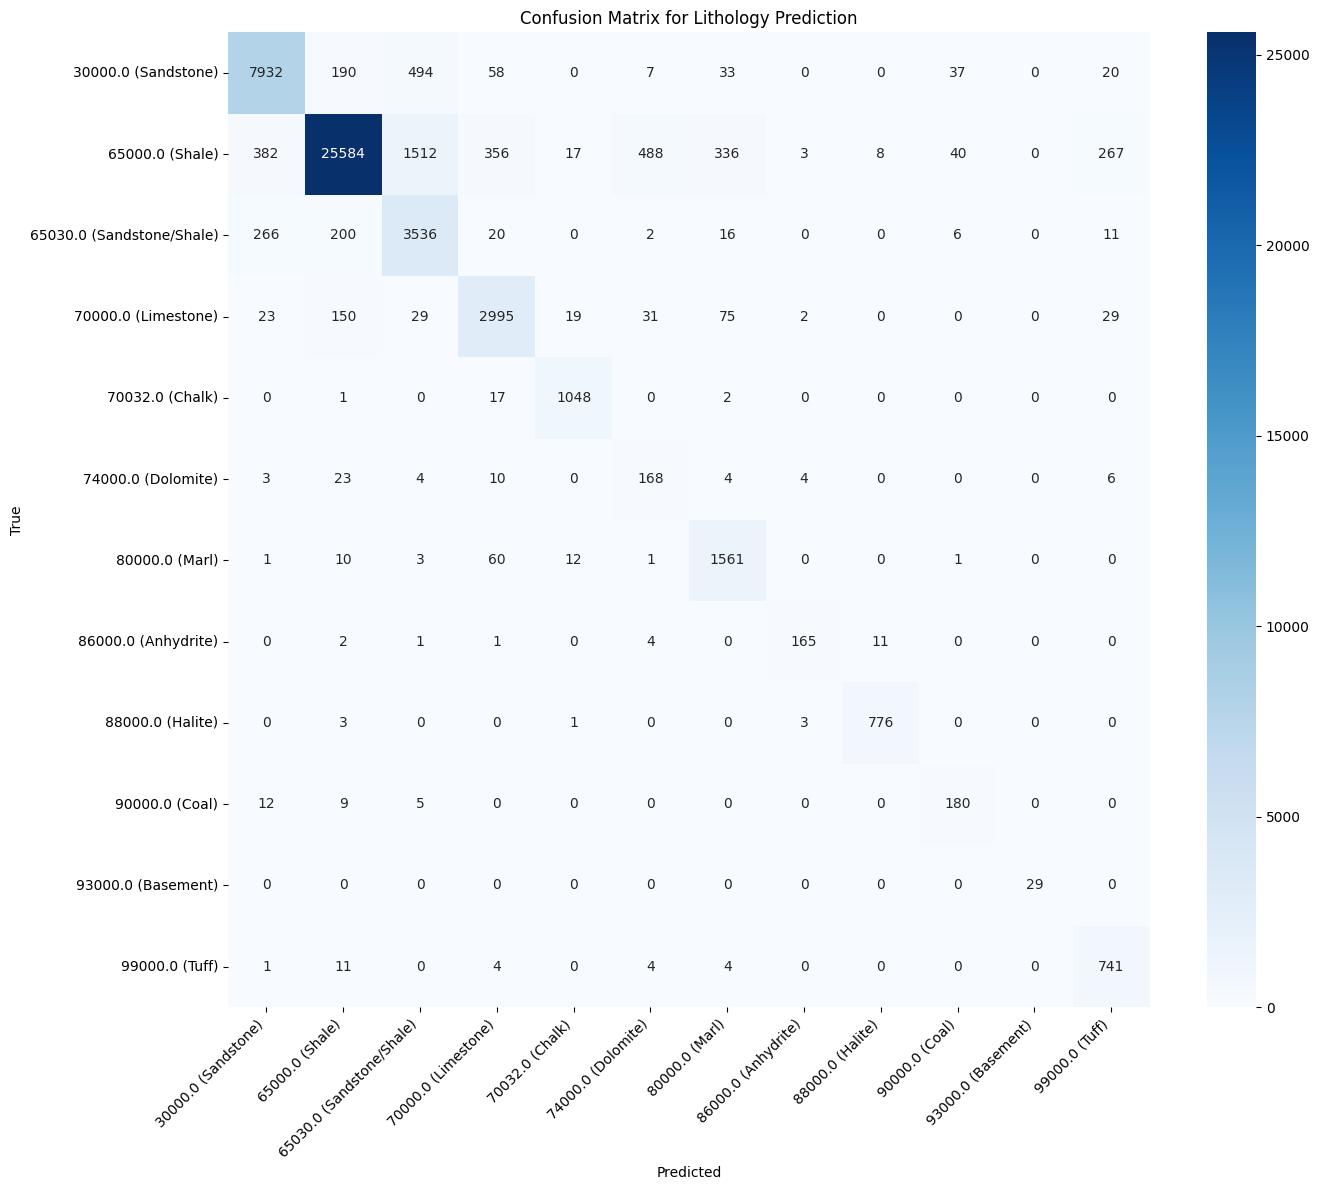

In [27]:


# Print simplified report in required format
print("\nClassification Report in required format:")
print("Classification Report:")
print("               precision    recall  f1-score   support")
for i, class_code in enumerate(model.classes_):
    precision = class_report[lithology_mapping.get(class_code, 'Unknown')]['precision']
    recall = class_report[lithology_mapping.get(class_code, 'Unknown')]['recall']
    f1 = class_report[lithology_mapping.get(class_code, 'Unknown')]['f1-score']
    support = class_report[lithology_mapping.get(class_code, 'Unknown')]['support']
    print(f"{class_code:8.1f} {precision:.2f}        {recall:.2f}     {f1:.2f}     {int(support)}")

print(f"accuracy                                          {class_report['accuracy']:.2f}     {int(class_report['weighted avg']['support'])}")
print(f"macro avg     {class_report['macro avg']['precision']:.2f}        {class_report['macro avg']['recall']:.2f}     {class_report['macro avg']['f1-score']:.2f}     {int(class_report['macro avg']['support'])}")
print(f"weighted avg  {class_report['weighted avg']['precision']:.2f}        {class_report['weighted avg']['recall']:.2f}     {class_report['weighted avg']['f1-score']:.2f}     {int(class_report['weighted avg']['support'])}")

# Generate and plot confusion matrix
print("\nGenerating confusion matrix...")
conf_matrix = confusion_matrix(y_valid, y_valid_pred)
class_names = [f"{code} ({lithology_mapping.get(code, 'Unknown')})" for code in model.classes_]

plt.figure(figsize=(14, 12))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Lithology Prediction')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('LGBM_8_800_lithology_confusion_matrix.png')
print("Confusion matrix saved as 'lithology_confusion_matrix.png'")

# Mengambil nilai pentingnya fitur
feature_importance = model.feature_importances_

# Menyusun indeks fitur berdasarkan tingkat kepentingannya
sorted_idx = np.argsort(feature_importance)


Feature importance plot saved as 'lithology_feature_importance.png'

F1 scores for critical lithology classes:
Sandstone: 0.9158
Shale: 0.9348
Sandstone/Shale: 0.7624
Sandstone-Shale confusion matrix saved as 'sandstone_shale_confusion.png'
Predictions saved to C:\Users\HP\Documents\SCALE-UP\SCALE-UP+ELIMINATION+ROUND+CASE+AND+PROBLEM\LGBM_8_800_lithology_predictions.csv


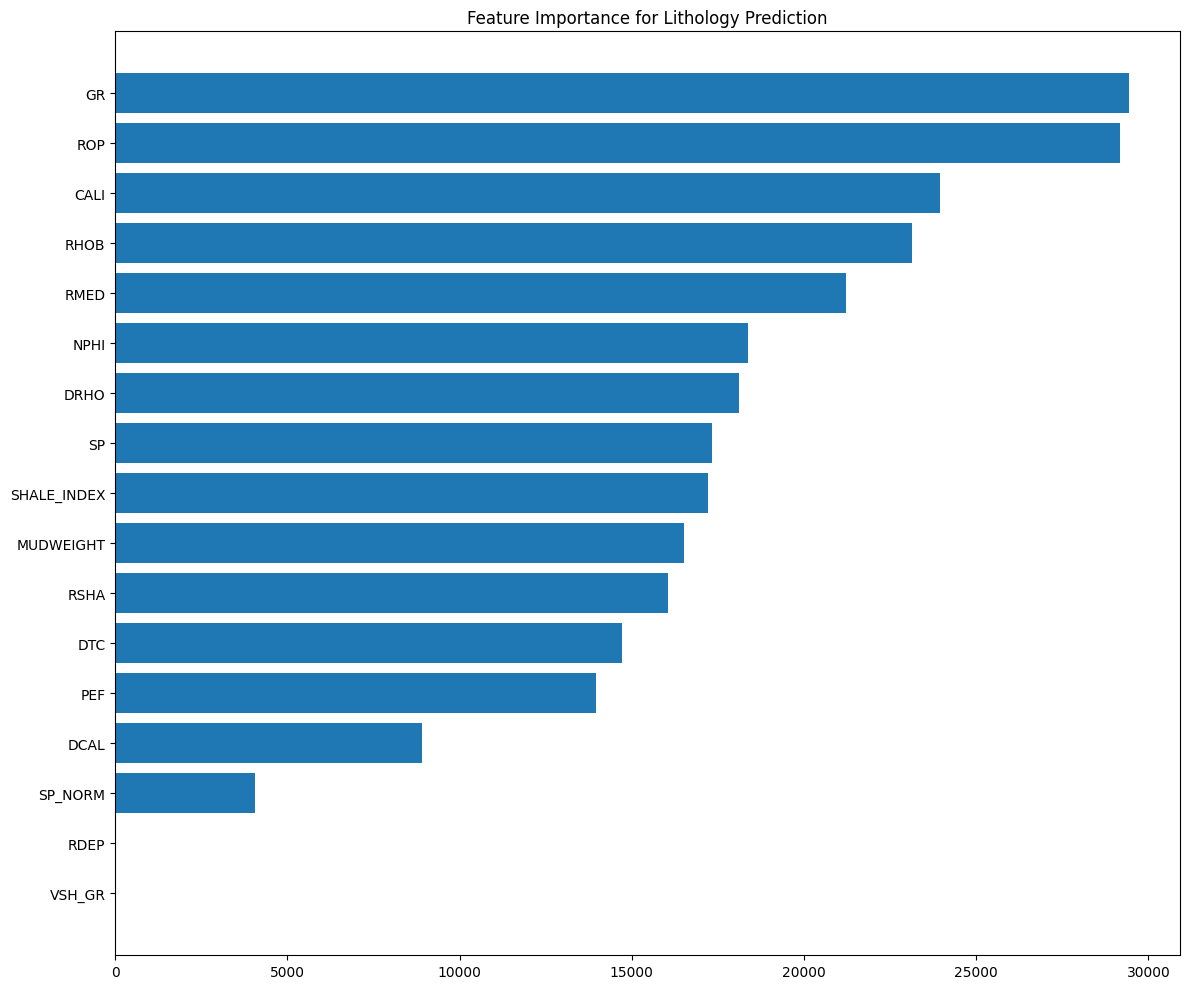

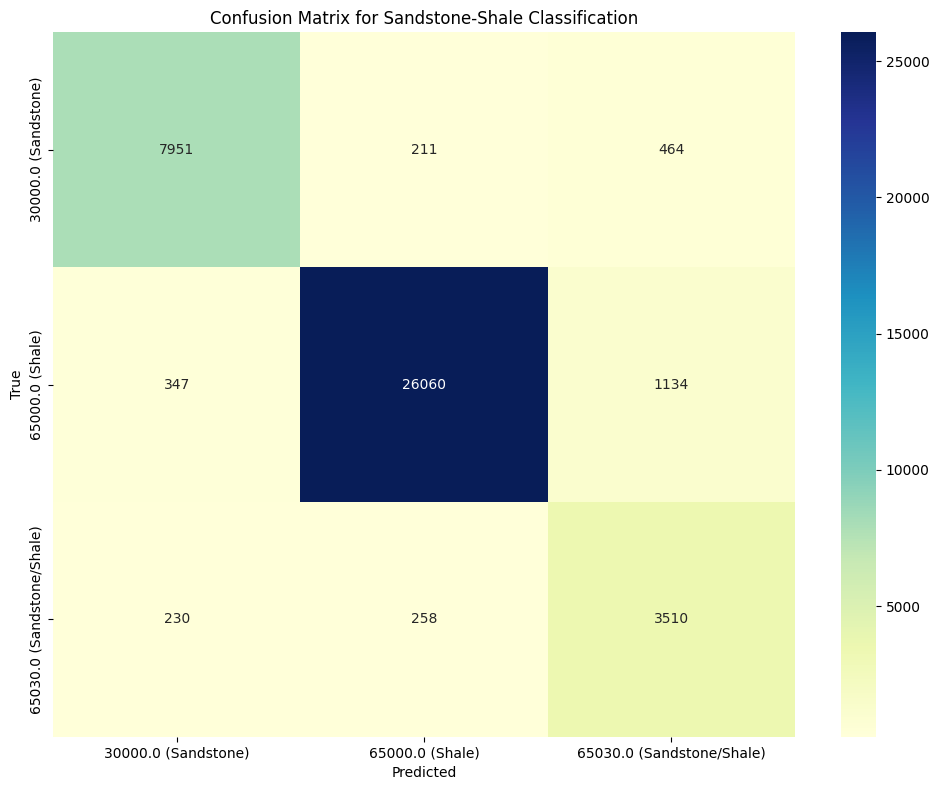

In [ ]:
# === FEATURE IMPORTANCE ===
# Get and plot feature importances
feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(12, 10))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
plt.title('Feature Importance for Lithology Prediction')
plt.tight_layout()
plt.savefig('LGBM_8_800_lithology_feature_importance.png')
print("Feature importance plot saved as 'lithology_feature_importance.png'")

# Predict on test data
X_test = test_data.drop(columns=['Lithology_code', 'file_name', 'well_name'] + 
                        [col for col in location_columns if col in test_data.columns], 
                        errors='ignore')

# Make sure test data has the same features as training data
for col in X.columns:
    if col not in X_test.columns:
        X_test[col] = 0  # Add missing columns with default values

# Ensure only training features are used
X_test = X_test[X.columns]

# Fill missing values in test set
X_test.fillna(X_train.median(numeric_only=True), inplace=True)

# Predict Lithology
y_pred = model.predict(X_test).ravel()

# Convert lithology codes to names based on mapping
y_pred_named = pd.Series(y_pred).map(lithology_mapping)

# Create output DataFrame
if 'uuid' in test_data.columns:
    output_df = pd.DataFrame({'uuid': test_data['uuid'][:len(y_pred)], 'label_name': y_pred_named})
else:
    output_df = pd.DataFrame({'uuid': range(len(y_pred)), 'label_name': y_pred_named})

# Save results
output_df.to_csv(OUTPUT_PATH, index=False)
print(f"Predictions saved to {OUTPUT_PATH}")